In [1]:
# START - retrieve - generate - END

In [3]:
# %pip install -qU pypdf
# %pip show pypdf

In [4]:
# 문서를 통으로 LLM에 전달하면 토큰 초과 문제가 발생할 수 있기 때문에, 문서를 쪼개서 벡터화하여 저장한 후, 검색을 통해 필요한 부분만 LLM에 전달하는 방식이 일반적이다.
# 비용 문제, 필요없는 정보까지 많은 컨텍스트를 제공하면 환각현상
# 필요한 문서만 쪼개서 전달해야 함 

In [5]:
%pip install -qU langchain-community langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file_path = "./docs/income_tax.pdf"
loader = PyPDFLoader(pdf_file_path)

pages = []
async for page in loader.alazy_load():
    pages.append(page)

# pages = []
# for page in loader.lazy_load():
#     pages.append(page)

# pages

In [8]:
pages[35]  # 필요한 55조 "표" 가 없이 바로 다음 내용으로 넘어간다. - 표가 이미지로 되어있기 때문
# 랭체인에서 기본으로 제공하는 pdf로더는 pdf 파일 안에 이미지를 파싱하지 못하기 때문에 쓸 수 없다

# 1. 챗 gpt를 활용하는 방법 -> PDF를 업로드 하여 테이블을 파싱하는 방법 (모든 문서에 대해서 일일히 이렇게 할 수 없다)
# 2. 파이썬 패키지 중에 zerox라고 있음 - LLM을 활용해서 OCR을 돌려서 문서를 인식하는 것
# pyzerox 패키지 설치 -> pip install pyzerox

Document(metadata={'producer': 'iText 2.1.7 by 1T3XT', 'creator': 'PyPDF', 'creationdate': '2025-01-10T10:55:01+09:00', 'moddate': '2025-01-10T10:55:01+09:00', 'source': './docs/income_tax.pdf', 'total_pages': 133, 'page': 35, 'page_label': '36'}, page_content='법제처                                                            36                                                       국가법령정보센터\n소득세법\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다\n)으로 한다.<개정 2013. 1. 1., 2014. 12. 23.>\n1. 해당 과세기간의 퇴직소득과세표준에 제1항의 세율을 적용하여 계산한 금액\n2. 제1호의 금액을 12로 나눈 금액에 근속연수를 곱한 금액\n3. 삭제<2014. 12. 23.>\n[전문개정 2009. 12. 31.]\n \n           제2관 세액공제 <개정 2009. 12. 31.>\n \n제56조(배당세액공제) ① 거주자의 종합소득금액에 제17조제3항 각 호 외의 부분 단서가 적용되는 배당소득금액이 합\n산되어 있는 경우에는 같은 항 각 호 외의 부분 단서에 따라 해당 과세기간의 총수입금액에 더한 금액에 해당하는\n금액을 종합소득 산출세액에서 공제한다. <개정 2009. 12. 31.>\n② 제1항에 따른 공제를 “배당세액공제”라 한다.<개정 2009. 12. 31.>\n③ 삭제<2003. 12. 30.>\n④ 제1항을 적용할 때 배당세액공제의 대상이 되는 배당소득금액은 제14조제2항의 종합소득과세표준에 포함된 배\n당소득금액으로서 이자소득등의 종합과세기준금액을 초

In [9]:
%pip install -q py-zerox

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from dotenv import load_dotenv


# Load environment variables from .env file
load_dotenv() 

True

In [12]:
%pip install -q nest-asyncio
# %pip show nest-asyncio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# # run the main function: 
# RuntimeError: asyncio.run() cannot be called from a running event loop
# result = asyncio.run(main()) 
# 아래 셀에서 에러 발생 -> 그래서, nest_asyncio 패키지를 활용하여 실행 후, 에러 해결 
import nest_asyncio
nest_asyncio.apply()

In [ ]:
# 소스코드 깃헙 복사
# LightLLM이라는 래퍼를 돌려서 OCR을 돌리기 때문에 모델 이름(Vertex ai까지 활용 가능)과 환경 변수를 주면 활용 가능
from pyzerox import zerox  # 버전 확인
import sys, os
import asyncio

# 환경변수에 bin을 등록해놔도 에러가 생김 -> 직접 코드로 넣어줌
poppler_bin_path = r"C:\poppler-24.08.0\Library\bin"
os.environ["PATH"] += os.pathsep + poppler_bin_path


### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###

## placeholder for additional model kwargs which might be required for some models
kwargs = {}

## system prompt to use for the vision model
custom_system_prompt = None

# to override
# custom_system_prompt = "For the below PDF page, do something..something..." ## example
###################### For other providers refer: https://docs.litellm.ai/docs/providers ######################
model = "gpt-4o-mini" ## openai model

# 파일 경로만 수정해주면 된다. 
# Define main async entrypoint
async def main():
    file_path = "./docs/income_tax.pdf" ## 문서 파일 경로
    ## process only some pages or all
    select_pages = None ## None for all, but could be int or list(int) page numbers (1 indexed)

    output_dir = "./docs" ## 결과를 저장할 경로
    result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
                        custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    return result

# encoding 문제? 
# sys.stdout.reconfigure(encoding="utf-8")  # AttributeError: 'OutStream' object has no attribute 'reconfigure' : 주피터 노트북에서는 이 에러가 남 -> py파일로 옮김
# sys.stderr.reconfigure(encoding="utf-8")

# 1. UnicodeEncodeError: 'cp949' codec can't encode character '\u278a' in position 51: illegal multibyte sequence
# 1-1. result = await main() 해도 "UnicodeEncodeError: 'cp949' codec can't encode character '\u2024' in position 686: illegal multibyte sequence" 에러가 뜬다. 
# 1.2. 일단 위 sys.stdout 코드를 살려서 진행해봄 - OutputStream 에러가 남
# 해결 : 아래 zerox 패키지 자체를 뜯어봄 

# run the main function:
result = asyncio.run(main())   # 에러 -> md파일을 강의자료에서 불러와서 다음단계 진행

print(result)


ZeroxOutput(completion_time=282447.147, file_name='income_tax', input_tokens=4904641, output_tokens=135837, pages=[Page(content='# 소득세법\n\n[시행 2025. 1. 1.] [법률 제20615호, 2024. 12. 31., 일부개정]\n\n기획재정부 (세제개편과)(양도소득세) 044-215-4312  \n기획재정부 (소득세과)(소득세) 044-215-4216  \n기획재정부 (세제개편과)(마이스, 비과세특소) 044-215-4233  \n기획재정부 (소득세과)(사업소득, 기타소득) 044-215-4217  \n\n---\n\n## 제1장 총칙\n\n### 제1조(목적)\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다.  \n[본조신설 2009. 12. 31.]  \n[종전 제1조는 제2조로 이동 <2009. 12. 31.>]\n\n### 제2조(정의)\n이 법에서 사용하는 용어의 뜻은 다음과 같다.  \n1. “거주자”란 국내에 주소를 두거나 183일 이상 거소(居所)를 둔 개인을 말한다.  \n2. “비거주자”란 거주자가 아닌 개인을 말한다.  \n3. “국내법인”이란 법인세법 제2조제1호에 따른 내국법인을 말한다.  \n4. “외국법인”이란 법인세법 제2조제3호에 따른 외국법인을 말한다.  \n5. “사사업자”란 사사업소에 있는 거주자를 말한다.  \n6. 제1항에 따른 소득⋅가사소득⋅비사업자의 구분은 대통령령으로 정한다.  \n[본조신설 2009. 12. 31.]\n\n### 제3조(납세의무)\n다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각각의 소득에 대한 소득세를 납부할 의무를 진다.  \n1. 거주자  \n2. 비거주자로서 국내원천소득(圓內源泉所得)이 있는 개인  \n3. 다음 각 호의 어느 하나에 해당하는 자는

- 위 코드에서 막혔던 이유
- 강의자료와 py-zerox 버전도 모두 확인 (0.0.7)로 동일했으나, 그래도 Unicode 에러가 뜸 -> 중국어와 같은 한자를 인식하지 못하는 문제가 원인
- 깃허브의 이슈사항을 보니, 패키지 자체 파일에서 encoding을 추가해주면 됨 -> IDE 끄고 다시 시작
```
        # Write the aggregated markdown to a file
        if output_dir:
            result_file_path = os.path.join(output_dir, f"{file_name}.md")
            async with aiofiles.open(result_file_path, "w", encoding="utf-8") as f:
                await f.write("\n\n".join(aggregated_markdown))
```

- 위 코드를 돌리면 43만개의 토큰이 나옴 -> md 파일 자체를 강의자료에서 다운받아서 다음 단계 진행

- md 파일 : 테이블 형식으로 잘 불러오는 것까지 확인

In [4]:
%pip install -q "unstructured[md]" nltk   
# unstructured 패키지 설치 - 마크다운 파일을 텍스트로 변환하기 위해서 필요
# unstructured 문서 파싱에서 유명한 미국 회사 + nltk는 자연어처리 패키지 -> 같이 쓰는 걸 추천 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# %pip show langchain_core
%pip install langchain_core

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=100, separators=["\n\n", "\n"])

In [7]:
from langchain_community.document_loaders import UnstructuredMarkdownLoader
from langchain_core.documents import Document

markdown_path = './docs/income_tax.md'
loader = UnstructuredMarkdownLoader(markdown_path)

# data = loader.load()
# assert len(data) == 1
# assert isinstance(data[0], Document)
# readme_content = data[0].page_content

# print(readme_content[:250])
document_list = loader.load_and_split(text_splitter)
document_list


[Document(metadata={'source': './docs/income_tax.md'}, page_content='소득세법\n\n[시행 2025. 1. 1.] [법률 제20615호, 2024. 12. 31., 일부개정]\n\n기획재정부 (세제개편과)(양도소득세) 044-215-4312 기획재정부 (소득세과)(소득세) 044-215-4216 기획재정부 (세제개편과)(마이스, 비과세특소) 044-215-4233 기획재정부 (소득세과)(사업소득, 기타소득) 044-215-4217\n\n제1장 총칙\n\n제1조(목적)\n\n이 법은 개인의 소득에 대하여 소득의 성격과 납세자의 부담능력 등에 따라 적정하게 과세함으로써 세부담의 형평을 도모하고 재정수입의 원활한 조달에 이바지함을 목적으로 한다. [본조신설 2009. 12. 31.] [종전 제1조는 제2조로 이동 <2009. 12. 31.>]\n\n제2조(정의)\n\n이 법에서 사용하는 용어의 뜻은 다음과 같다. 1. “거주자”란 국내에 주소를 두거나 183일 이상 거소(居所)를 둔 개인을 말한다. 2. “비거주자”란 거주자가 아닌 개인을 말한다. 3. “국내법인”이란 법인세법 제2조제1호에 따른 내국법인을 말한다. 4. “외국법인”이란 법인세법 제2조제3호에 따른 외국법인을 말한다. 5. “사사업자”란 사사업소에 있는 거주자를 말한다. 6. 제1항에 따른 소득⋅가사소득⋅비사업자의 구분은 대통령령으로 정한다. [본조신설 2009. 12. 31.]\n\n제3조(납세의무)\n\n다음 각 호의 어느 하나에 해당하는 개인은 이 법에 따라 각각의 소득에 대한 소득세를 납부할 의무를 진다. 1. 거주자 2. 비거주자로서 국내원천소득(圓內源泉所得)이 있는 개인 3. 다음 각 호의 어느 하나에 해당하는 자는 이 법에 따라 원천징수한 소득세를 납부할 의무를 진다. 1. 거주자 2. 비거주자 3. 납세의무인 4. 외국법인에게 국내영업소(出張所, 그 밖에 이에 준하는 것을 포함한다. 이하 같다) 5. 그 밖에 이 법에 의한 원천징수

In [8]:
document_list[40]   # md는 잘 들어왔는데 표가 잘림 -> 표 형태가 아닌 줄글로 되어있음

# 그래서 그대로 사용하면, 제대로 학습해서 정답이 나올 수 있겠지만, 정확한 컨텍스트를 전달하는 게 아니게 됨 
# md - txt - load - split 의 과정을 거쳐야 한다 

Document(metadata={'source': './docs/income_tax.md'}, page_content='제56조 세액의 계산\n\n<개정 2009. 12. 31.>\n\n제1관 세율\n\n<개정 2009. 12. 31.>\n\n제55조(세율)\n\n① 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액에 (아래 "종합소득산출세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n\n종합소득 세 1,400만 원 이하 과세표준의 6세트넷 1,400만 원 초과 84만 원 + (1,400만 원을 초과하는 금액의 15퍼센트) 5,000만 원 이하 624만 원 + (5,000만 원을 초과하는 금액의 24퍼센트) 8,000만 원 이하 1,536만 원 + (8,800만 원을 초과하는 금액의 35퍼센트) 1억 원 이하 3,706만 원 + (1억 5,000만 원을 초과하는 금액의 38퍼센트) 3억 원 이하 9,406만 원 + (3억 원을 초과하는 금액의 40퍼센트) 5억 원 이하 1억 760만 원 + (5억 원을 초과하는 금액의 42퍼센트) 10억 원 이하 3억 406만 원 + (10억 원을 초과하는 금액의 45퍼센트)\n\n법제처 35 국가법령정보센터\n\n소득세법\n\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다. <개정> 2013. 1. 1, 2014. 12. 23. > 1. 해당 사업기간에 퇴직소득세표준에 제1항의 세율을 적용하여 계산한 금액 2. 제1호의 금액을 12로 나눈 금액에 근속연수를 곱한 금액 3. 삭제<2014. 12. 23.> <전문개정 2009. 12. 31.>\n\n제2장 세액공제 <개정 2009. 12. 31.>\n\n제56조(배당소득의 공제) ① 거주자의 종합소득금액에 제17조제3항 각

- 마크다운 테이블을 활용하기 위해 `.md` -> `.txt`로 변환합니다

In [9]:
%pip install -q markdown html2text beautifulsoup4
# %pip show markdown html2text beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# text 변환

import markdown
from bs4 import BeautifulSoup

text_path = './docs/income_tax.txt'

# 마크다운 파일을 읽어옵니다
with open(markdown_path, 'r', encoding='utf-8') as md_file:
    md_content = md_file.read()

# 마크다운 콘텐츠를 HTML로 변환합니다
html_content = markdown.markdown(md_content)

# HTML 콘텐츠를 파싱하여 텍스트만 추출합니다
soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

# 추출한 텍스트를 텍스트 파일로 저장합니다
with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")  # txt 파일 들어가보면, encoding을 euc로 하지 않아도 utf-8로 잘 저장된 것을 볼 수 있다.

Markdown converted to plain text successfully!


- txt파일을 로딩

```
markdown(md) 을 text(txt) 로 변환한 다음에 load 하고 split 을 해줘야함

txt 로 변환된 건 langchain 의 textloader 를 써서 load 해야함
이때, utf-8로 encoding 된 txt 파일을 langchain_community 로 TextLoader 하려고 할때 encoding 을 안쓰게 되면 cp949 에러가 나게 됩니다.
```
 

In [12]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader(text_path,  encoding='utf-8')  # ✅ 인코딩 명시! : 에러 발생함
document_list = loader.load_and_split(text_splitter)


In [13]:
document_list[47]   # 표가 잘 들어가있음을 확인할 수 있다 

Document(metadata={'source': './docs/income_tax.txt'}, page_content='[제목개정 2014. 1. 1.]\n제56조 세액의 계산\n<개정 2009. 12. 31.>\n제1관 세율\n<개정 2009. 12. 31.>\n제55조(세율)\n① 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액에 (아래 "종합소득산출세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n| 종합소득          | 세   |\n|-------------------|------|\n| 1,400만 원 이하   | 과세표준의 6세트넷 |\n| 1,400만 원 초과   | 84만 원 + (1,400만 원을 초과하는 금액의 15퍼센트) |\n| 5,000만 원 이하    | 624만 원 + (5,000만 원을 초과하는 금액의 24퍼센트) |\n| 8,000만 원 이하    | 1,536만 원 + (8,800만 원을 초과하는 금액의 35퍼센트) |\n| 1억 원 이하       | 3,706만 원 + (1억 5,000만 원을 초과하는 금액의 38퍼센트) |\n| 3억 원 이하       | 9,406만 원 + (3억 원을 초과하는 금액의 40퍼센트) |\n| 5억 원 이하       | 1억 760만 원 + (5억 원을 초과하는 금액의 42퍼센트) |\n| 10억 원 이하      | 3억 406만 원 + (10억 원을 초과하는 금액의 45퍼센트) |\n법제처 35\n국가법령정보센터\n소득세법\n② 거주자의 퇴직소득에 대한 소득세는 다음 각 호의 순서에 따라 계산한 금액(이하 “퇴직소득 산출세액”이라 한다)으로 한다. <개정> 2013. 1. 1, 2014. 12. 23. >\n1. 해당 사업기간에 퇴직소득세표준에 제1항의 세율을 적용하여 계산한 금액\n2. 제1호의 

### Vector DB 적재

In [14]:
%pip install -q langchain-chroma
# %pip show langchain-chroma

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [16]:
# vector store 생성

from langchain_chroma import Chroma

vector_store = Chroma.from_documents(
    documents=document_list,
    embedding=embeddings,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection'  # 로컬에 남아있음
)

In [17]:
retriever = vector_store.as_retriever(search_kwargs={'k':3})

In [18]:
query = '연봉 5천만원 직장인의 소득세는?'
retriever.invoke(query)  # 문서를 반환

[Document(id='ae5669ef-f49c-4f5c-91b9-bc280eb0f852', metadata={'source': './docs/income_tax.txt'}, page_content='만일 이하의 자기 주택임대소득(2018년 12월 31일 이전에 말하는 과세기간까지 발생하는 소득으로 한정한다.\n다. 대통령령으로 정하는 정년보장제도에 발생하는 소득\n라. 대통령령으로 정하는 전적소득 제도에 발생하는 소득\n마. 조기퇴직 그 내 이상의 임징(任職)에서 원익 또는 양으로 발생하는 소득으로 연 600만원 이하의 금액에, 의 경우 조기퇴직 인 원의 필요와 사유로 발생하는 소득으로 정한다.\n바. 대통령령으로 정하는 작업재배형에서 발생하는 소득\n사. 대통령령으로 정하는 매도나 양식업에서 발생하는 소득'),
 Document(id='3e22b807-bb17-4645-a6d6-8afb6ce670a6', metadata={'source': './docs/income_tax.txt'}, page_content='소득세법\n은 급여를 포함한다) 전액\n2) 근로소득 또는 배급자의 해당 과세기간 개시일을 기준으로 6세 이하(6세가 되는 날) 그 이전 기간을 말한\n다. 이하 이 조 및 제조조에 있어 같단다) 나 이사 보육과 관련한 사용자로부터 지급받은 금여로 월\n20만원 이내의 금액  \n나. \'국고지불\' 승환 및 대우 5에 관한 법률에 따라 국가로부터 받는 보수 및 퇴직신청\n서, \'교육비법\', 제2조제1항에 따라 받은 장학금 중 대학장중 근로를 대가로 지급받는 장학금(고등교육법,\n제2조제1호부터 제4호까지 규정에 의해 대학교에 재학하는 대학생에 한정함)\n라. 담당직종별, 제2조제6항에 따른 직무발명으로 받는 다음의 보상금(이하 "직무발명보상금"이라 한다)으로서\n대통령령으로 정하는 금액\n    1) 법령지정법 제2조제1항에 따른 용역비(이하 \'2조\', 제20조 및 제2조에서 \'중업원들\'이라 한다)와\n   은 초에 따른 사용자(이하 \

In [11]:
# START - retrieve - generate(답변 생성) -  END

- langgraph 빌드

In [19]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str   # 사용자의 질문
    context:List[Document]  # 답변을 만들때 참고할 문서들 - langchain의 다큐먼트들을 리스트 형태로 반환 
    answer: str

In [20]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)  # 빌더 생성

In [21]:
# 노드 생성 : 1. retrieve, generate 노드 필요

# retrieve
def retrieve(state:AgentState):
    query = state['query']  # 사용자의 질문을 꺼내온다
    docs = retriever.invoke(query)  # 사용자의 질문을 가지고 문서 검색
    return {'context' : docs}  


In [22]:
from langchain_classic import hub
from langchain_openai import ChatOpenAI

prompt = hub.pull("rlm/rag-prompt")
llm = ChatOpenAI(model='gpt-4o-mini')  # 가격을 위해서 mini로 대체

# generate
# 주의 : 사용자의 질문만 넣어서 invoke를 했었던 기본 반식에서 벗어나, -> context를 같이 넣어줘야 한다 -> 그래서 rag의 효율적인 프롬프트를 작성해줘야 한다. (langsmith의 프롬프트허브를 활용하자)
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    # LCEL 기반 체이닝 : LLM을 invoke하지 않고, 선언한 프롬프트를 기반으로 LLM을 호출해야 한다
    rag_chain = prompt | llm
    response = rag_chain.invoke({'question': query, 'context':context})
    return {'answer' : response}

In [23]:
# 노드 추가
graph_builder.add_node('retrieve',retrieve)
graph_builder.add_node('generate',generate)

In [24]:
# START, END 
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)


In [25]:
# 컴파일
graph = graph_builder.compile()

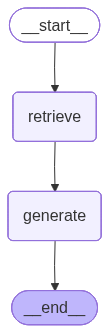

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  # 시퀀스 다이어그램으로 노드 간의 흐름을 볼 수 있다 
# 시퀀스는 일일히 노드와 엣지를 추가하는 과정을 거치지 않아도 된다

### 시퀀스 
- 노드와 엣지 생성과 다른 방법
- 코드가 간단해진다

In [30]:
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])  # StateGraph에 sequence 가 들어간것

In [31]:
sequence_graph_builder.add_edge(START, 'retrieve')
sequence_graph_builder.add_edge('generate', END)

# start 와 end 만 연결해주면, sequence로 알아서 retrieve - generate 순으로 노드가 연결이 된다.

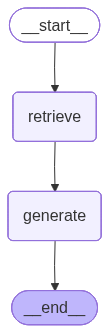

In [32]:
sequence_graph = sequence_graph_builder.compile()
display(Image(sequence_graph.get_graph().draw_mermaid_png()))  

In [34]:
# 호출

initial_state = {'query': query}
graph.invoke(initial_state)

# 결과를 보면, "답변에 필요한 정보가 제공되지 않아~" 라고 나옴 -> 사용자의 질문이 retrieve를 할 때, 효율이 떨어지는 질문이기 때문
# 여기서 conditional edge를 활용 -> 생성한 답변이 좋으면 generate로, 나쁘면 사용자의 질문을 rewrite로 가도록 하는 것 

{'query': '연봉 5천만원 직장인의 소득세는?',
 'context': [Document(id='ae5669ef-f49c-4f5c-91b9-bc280eb0f852', metadata={'source': './docs/income_tax.txt'}, page_content='만일 이하의 자기 주택임대소득(2018년 12월 31일 이전에 말하는 과세기간까지 발생하는 소득으로 한정한다.\n다. 대통령령으로 정하는 정년보장제도에 발생하는 소득\n라. 대통령령으로 정하는 전적소득 제도에 발생하는 소득\n마. 조기퇴직 그 내 이상의 임징(任職)에서 원익 또는 양으로 발생하는 소득으로 연 600만원 이하의 금액에, 의 경우 조기퇴직 인 원의 필요와 사유로 발생하는 소득으로 정한다.\n바. 대통령령으로 정하는 작업재배형에서 발생하는 소득\n사. 대통령령으로 정하는 매도나 양식업에서 발생하는 소득'),
  Document(id='3e22b807-bb17-4645-a6d6-8afb6ce670a6', metadata={'source': './docs/income_tax.txt'}, page_content='소득세법\n은 급여를 포함한다) 전액\n2) 근로소득 또는 배급자의 해당 과세기간 개시일을 기준으로 6세 이하(6세가 되는 날) 그 이전 기간을 말한\n다. 이하 이 조 및 제조조에 있어 같단다) 나 이사 보육과 관련한 사용자로부터 지급받은 금여로 월\n20만원 이내의 금액  \n나. \'국고지불\' 승환 및 대우 5에 관한 법률에 따라 국가로부터 받는 보수 및 퇴직신청\n서, \'교육비법\', 제2조제1항에 따라 받은 장학금 중 대학장중 근로를 대가로 지급받는 장학금(고등교육법,\n제2조제1호부터 제4호까지 규정에 의해 대학교에 재학하는 대학생에 한정함)\n라. 담당직종별, 제2조제6항에 따른 직무발명으로 받는 다음의 보상금(이하 "직무발명보상금"이라 한다)으로서\n대통령령으로 정하는 금액\n    1) 법령지정법 제2조제1항에 따른 용역비(이하 \'2조\', 제20조